In [1]:
import wandb

import pandas as pd

from tqdm import tqdm

from matplotlib import pyplot as plt

import numpy as np 

from xaikd import models, datasets

from torch.utils.data import DataLoader
from xaikd.utils import metrics

In [2]:
api = wandb.Api()

In [10]:
EXPERIMENT_GROUP = "tmp/improve-learnlin--run9-influence-layerpolicy"

In [81]:
def read_data(
    teacher,
    student,
    basis_name,
    lambda_task,
    lambda_layer,
    dataset,
    training_size,
    arr_layers,
    verbose=False,
    
):
    
    
    runs = api.runs(
        f'p16i/xaikd-distillation-layerwise',
        {
        "$and": [
            {"group": EXPERIMENT_GROUP},
            {"config.teacher": teacher},
            {"config.student": student},
            {"config.lambda_task": lambda_task},
            {"config.lambda_layer": {"$in": [lambda_layer]}},
            {"config.policy": basis_name},
            {"config.training_size": training_size},
            {"config.dataset": dataset},
            {"config.layers": {"$in": arr_layers}}
        ]}
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    for run in runs:
        seed = run.config["seed"]
         
        
        k = np.argmax(run.summary["arr_metrics"]["val_acc"])
        best_val_acc = run.summary["arr_metrics"]["val_acc"][k]
        best_val_agreement = run.summary["arr_metrics"]["val_agreement"][k]
        best_val_agreement_on_teacher_correct = run.summary["arr_metrics"]["val_agreement_on_teacher_correct"][k]


        rows.append(
            dict(
                seed=seed, 
                layers=run.config["layers"],
                lambda_kd=run.config["lambda_kd"],
                lambda_layer=run.config["lambda_layer"],
                val_acc=best_val_acc, 
                val_agreement=best_val_agreement,
                val_agreement_on_teacher_correct=best_val_agreement_on_teacher_correct,
                teacher_acc=run.summary["teacher_acc"]
            )
        )

    
    df = pd.DataFrame(rows)
        
    df = df.groupby(by="layers").agg(
        {
            "val_acc": ["mean", "std", "count"],
            "val_agreement": ["mean", "std", "count"],
            "val_agreement_on_teacher_correct": ["mean", "std", "count"],
            "teacher_acc": ["mean"]
        }
    ).reset_index()
    if verbose:
        print(f"df.shape: {df.shape}")
    return df

summary = read_data(
    teacher="cifar100-resnet18-wb15",
    student="resnet18compr2",
    lambda_task=0.0,
    lambda_layer=0.5,
    basis_name="basis:pca",
    training_size=1.0,
    verbose=True,
    dataset="cifar100-people",
    arr_layers=[
        "layer1,layer2,layer3,layer4",
        "layer2,layer3,layer4",
        "layer3,layer4",
        "layer4"
    ]
)

summary

we have 4 runs
df.shape: (4, 11)


layers val_acc           val_agreement            \
                                  mean std count          mean std count   
0  layer1,layer2,layer3,layer4   0.594 NaN     1         0.600 NaN     1   
1         layer2,layer3,layer4   0.584 NaN     1         0.604 NaN     1   
2                layer3,layer4   0.590 NaN     1         0.564 NaN     1   
3                       layer4   0.608 NaN     1         0.584 NaN     1   

  val_agreement_on_teacher_correct           teacher_acc  
                              mean std count        mean  
0                            0.466 NaN     1       0.624  
1                            0.462 NaN     1       0.624  
2                            0.448 NaN     1       0.624  
3                            0.470 NaN     1       0.624

# Comparison on `cifar100-resnet18-wb15`

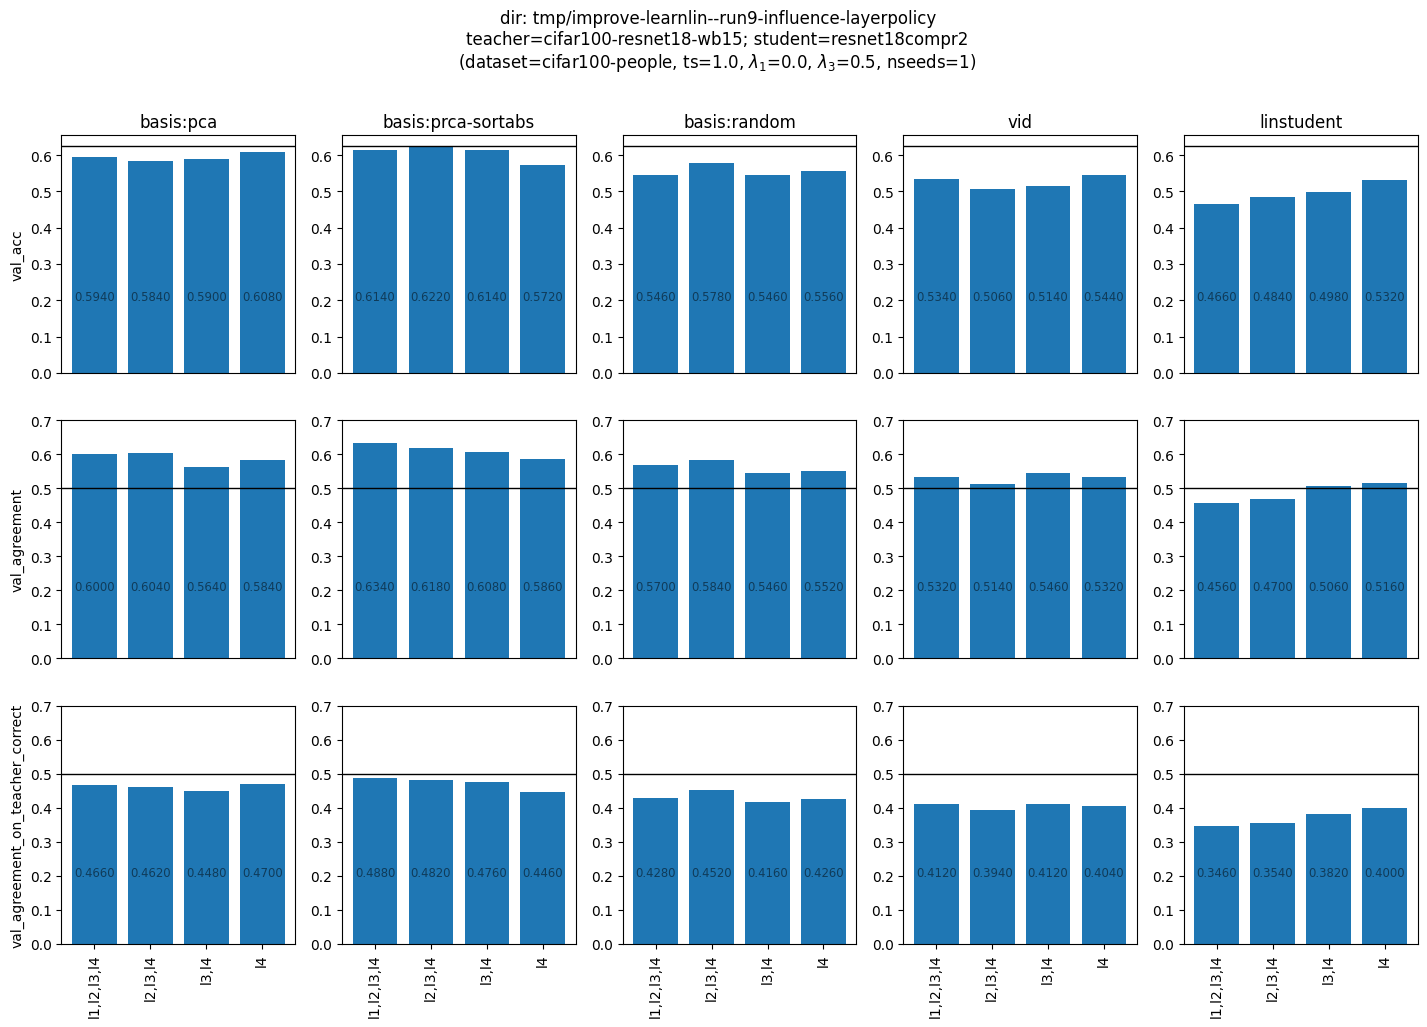

In [89]:
def ls(basis_name):
    if "random" in basis_name:
        return ":"
    elif basis_name == "linstudent":
        return "--"
    else:
        return "-"
    
def color(basis_name):
    if "random" in basis_name:
        return "gray"
    else:
        return None
    
def viz_distillation(teacher, student, lambda_layer):
        
    dataset = "cifar100-people"
    lambda_task = 0.0
    training_size = 1.0
    
    policies = [ 
        "basis:pca",
        "basis:prca-sortabs",
        "basis:random",
        "vid",
        "linstudent"
    ]
        
    
    arr_layers = [
        "layer1,layer2,layer3,layer4",
        "layer2,layer3,layer4",
        "layer3,layer4",
        "layer4"
    ]
    
    
    arr_layers_short = list(map(lambda t: t.replace("layer", "l"), arr_layers))
    
    columns = ["val_acc", "val_agreement", "val_agreement_on_teacher_correct"]

    
    
    ncols = len(policies)
    nrows = len(columns)
    
    plt.figure(figsize=(3.5*ncols, 3.5*nrows))
    
    dirslug = "/".join(f"{EXPERIMENT_GROUP}".split("/")[-2:])

    
    ticks = list(range(len(arr_layers)))
    
    for pix, policy in enumerate(policies):
        for cix, col in enumerate(columns):
            df = read_data(
                teacher=teacher,
                student=student,
                lambda_task=lambda_task,
                lambda_layer=lambda_layer,
                arr_layers=arr_layers,
                dataset=dataset,
                basis_name=policy,
                training_size=training_size,
            )

            plt.subplot(nrows, ncols, pix + cix * ncols + 1)
            if pix == 0:
                plt.ylabel(col)
            
            if cix == 0:
                plt.title(policy)

            if cix == nrows - 1:
                plt.xticks(
                    ticks,
                    arr_layers_short,
                    rotation=90
                )
            else:
                plt.xticks([])
            
            count = df[col]["count"][0]
            
            values =  df[col]["mean"]
            if col == "val_acc":
                plt.axhline(df["teacher_acc"]["mean"][0], ls="-", color="k", lw=1)
            else:
                plt.axhline(0.5, ls="-", color="k", lw=1)
                plt.ylim(top=0.7)

            plt.bar(ticks, values)
            
            for t, v in zip(ticks, values):
                plt.text(t, 0.2, f"{v:.4f}", alpha=0.5, ha="center", fontsize="small")
            


    plt.suptitle(
        "\n".join([
            f"dir: {dirslug}",
            f"teacher={teacher}; student={student}",
            f"(dataset={dataset}, ts={training_size}, $\lambda_1$={lambda_task}, $\lambda_3$={lambda_layer}, nseeds={count})",
        ]),
        y=1.0
    )

viz_distillation(
    teacher = "cifar100-resnet18-wb15",
    student="resnet18compr2",
    lambda_layer=0.5
) 

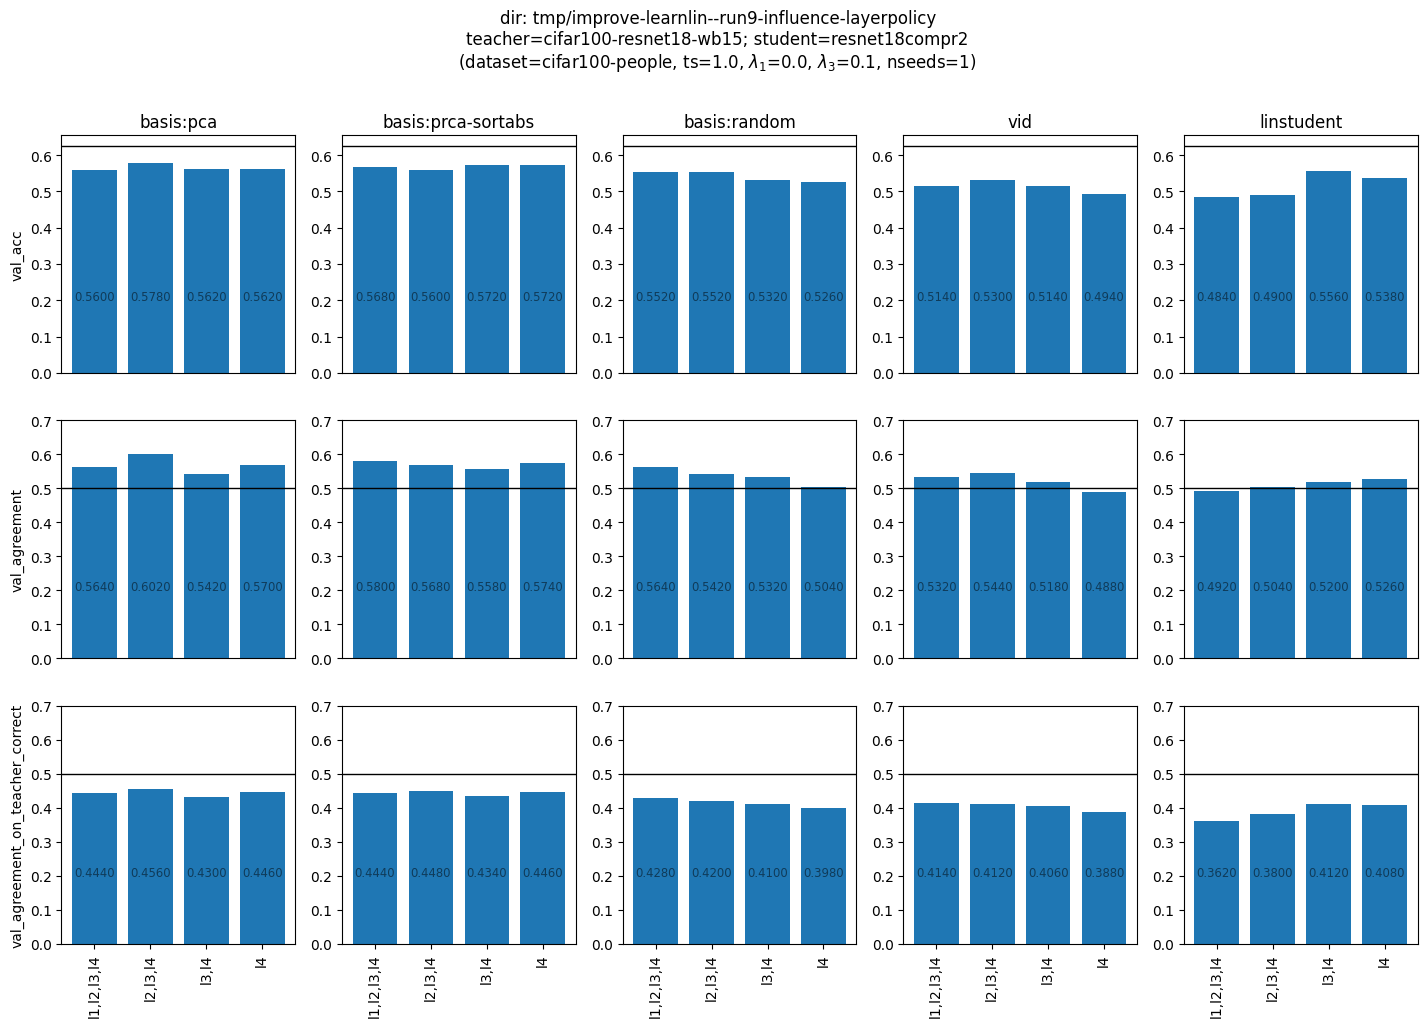

In [90]:
viz_distillation(
    teacher = "cifar100-resnet18-wb15",
    student="resnet18compr2",
    lambda_layer=0.1
) 

# Summary (to be revisited)

Setup:
$$
 (0.0) \ell_\text{task} + \lambda_2 \ell_\text{KD} + \lambda_3 \ell_\text{layer},
$$
$\lambda_2 = 1- \alpha$ and $\lambda_3 = \alpha$

where  $\alpha \in \{0.1, 0.5\}$.

*Aims:* 
- investigate whether the efficacy of layer loss when varing the choice of layers.



*Conclusion:*
- when $\alpha=0.5$, we could see that having the layer loss at more layers tend to improve performance.
    - the reason  we do NOT see such effect on $\alpha=0.1$ is because the KD loss dominates the learning.